# 1. Problem Statement

This notebook addresses the **Classification Track** of the ML Capstone Project (Review 1, Part A).

**Dataset:** Student records from a higher-education institution, containing demographic, socio-economic,
and academic-performance information collected at the time of enrollment and at the end of the first and
second semesters.

**Task:** Predict the `Target` column, which records the student's academic outcome at the end of the
course, using the other 36 columns as input features. This is a **multi-class classification** problem
with three possible outcomes: `Dropout`, `Enrolled`, and `Graduate`.

**Why the target column is not ambiguous:** the dataset ships with a column literally named `Target`
containing exactly three categorical outcome labels (`Dropout`, `Enrolled`, `Graduate`), while every other
column is a numerically-coded predictor (demographics, admission data, or semester performance). There is
no other plausible label column, so `Target` was used directly without needing to ask for clarification.

# 2. Dataset Description

- **Rows:** 4,424 students
- **Columns:** 37 (36 features + 1 target)
- **Target:** `Target` — three classes: `Dropout`, `Enrolled`, `Graduate`
- **Feature groups:**
  - Demographic: `Marital status`, `Nacionality`, `Gender`, `Age at enrollment`, `International`
  - Socio-economic: `Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`,
    `Scholarship holder`, `Mother's/Father's qualification`, `Mother's/Father's occupation`,
    `Unemployment rate`, `Inflation rate`, `GDP`
  - Academic/admission: `Application mode`, `Application order`, `Course`,
    `Daytime/evening attendance`, `Previous qualification` (+ grade), `Admission grade`
  - Semester performance (1st and 2nd semester): credited / enrolled / evaluations / approved
    curricular units, and semester grade

This description is based directly on the columns present in the dataset audit below — no additional
columns were invented.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.autolayout"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# Load the actual classification dataset
df = pd.read_csv("../data/data.csv", sep=";", encoding="utf-8-sig")

# Clean stray tab characters and whitespace from column names
df.columns = [c.replace("\t", "").strip() for c in df.columns]

# Display first few rows
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 5. Dataset Audit

In [9]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (4424, 37)


In [10]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [12]:
print("Data types:")
print(df.dtypes.value_counts())
print()
print("Missing values per column (top 10 shown):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print()
print("Total missing values in dataset:", df.isnull().sum().sum())

Data types:
int64      29
float64     7
object      1
Name: count, dtype: int64

Missing values per column (top 10 shown):
Marital status                    0
Application mode                  0
Application order                 0
Course                            0
Daytime/evening attendance        0
Previous qualification            0
Previous qualification (grade)    0
Nacionality                       0
Mother's qualification            0
Father's qualification            0
dtype: int64

Total missing values in dataset: 0


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print()
print("Numerical columns (%d):" % len(numerical_cols))
print(numerical_cols)

Categorical columns: ['Target']

Numerical columns (36):
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemploymen

In [15]:
print("Target class distribution (counts):")
print(df["Target"].value_counts())
print()
print("Target class distribution (%):")
print((df["Target"].value_counts(normalize=True) * 100).round(2))

Target class distribution (counts):
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target class distribution (%):
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


# 6. Exploratory Data Analysis

## 6.1 Target / Class Distribution

C:\Users\DELL\AppData\Local\Temp\ipykernel_18616\2933812273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Target", order=order, ax=ax, palette="colorblind")


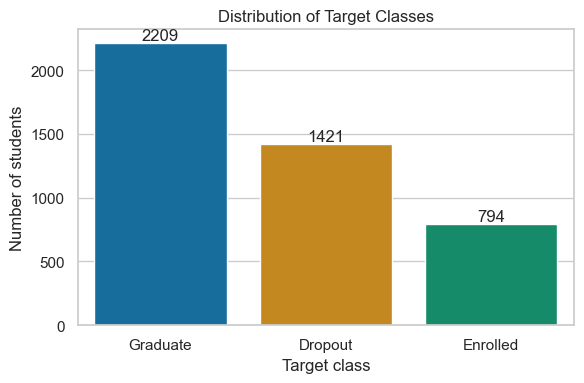

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df["Target"].value_counts().index
sns.countplot(data=df, x="Target", order=order, ax=ax, palette="colorblind")
ax.set_title("Distribution of Target Classes")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of students")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 6.2 Feature Distributions (selected numerical features)

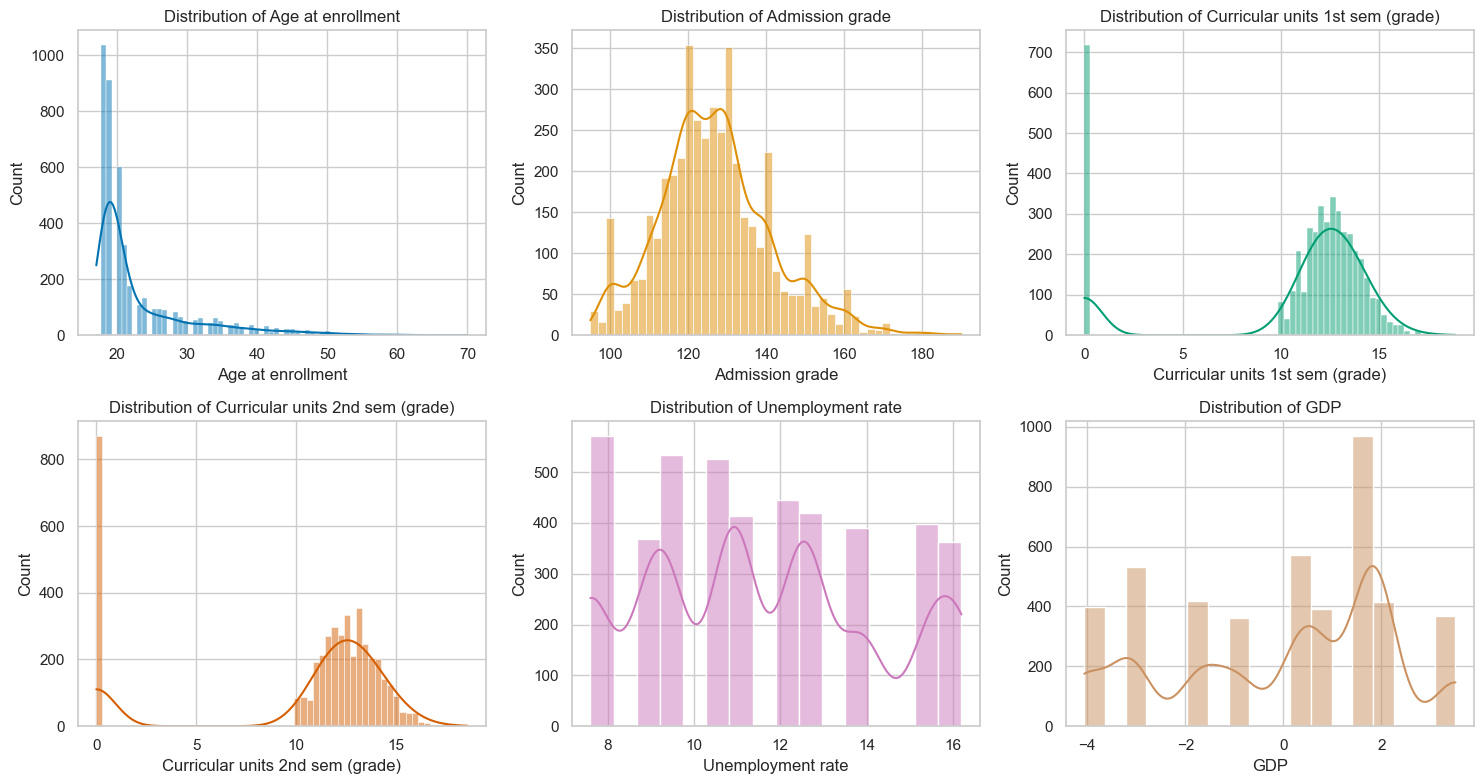

In [17]:
num_features_to_plot = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "GDP",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_features_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("colorblind")[i % 6])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

## 6.3 Correlation Heatmap (numerical features)

In [ ]:
plt.figure(figsize=(16, 12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 6.4 Feature-vs-Target Relationships

C:\Users\DELL\AppData\Local\Temp\ipykernel_18616\1382175685.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)", order=order, ax=ax, palette="colorblind")


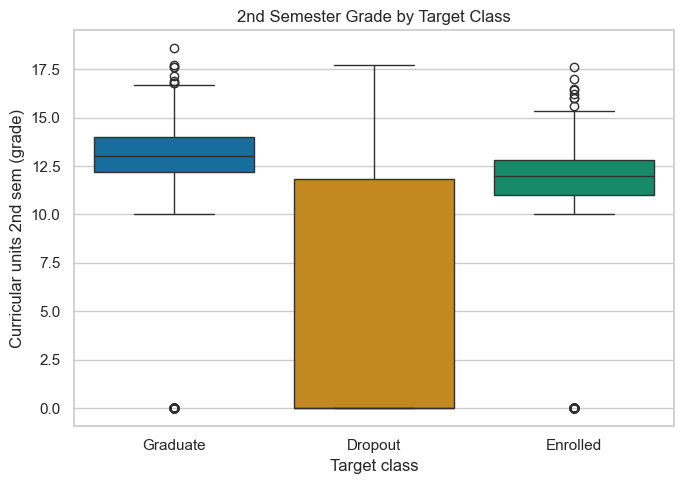

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)", order=order, ax=ax, palette="colorblind")
ax.set_title("2nd Semester Grade by Target Class")
ax.set_xlabel("Target class")
ax.set_ylabel("Curricular units 2nd sem (grade)")
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18616\3482150042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Admission grade", order=order, ax=ax, palette="colorblind")


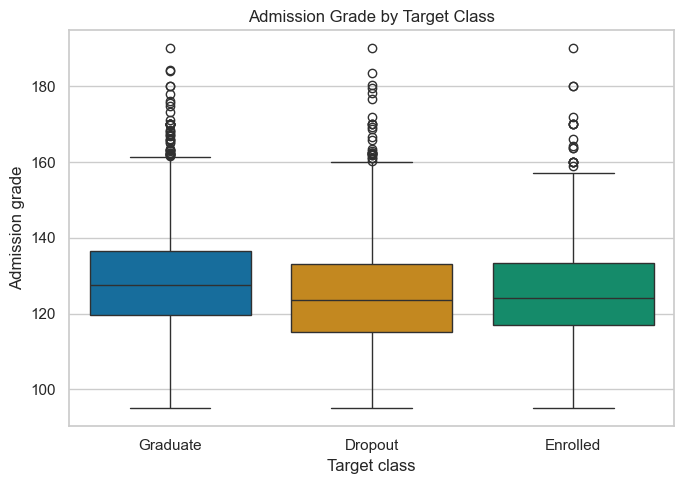

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Admission grade", order=order, ax=ax, palette="colorblind")
ax.set_title("Admission Grade by Target Class")
ax.set_xlabel("Target class")
ax.set_ylabel("Admission grade")
plt.tight_layout()
plt.show()

## 6.5 Outlier Inspection

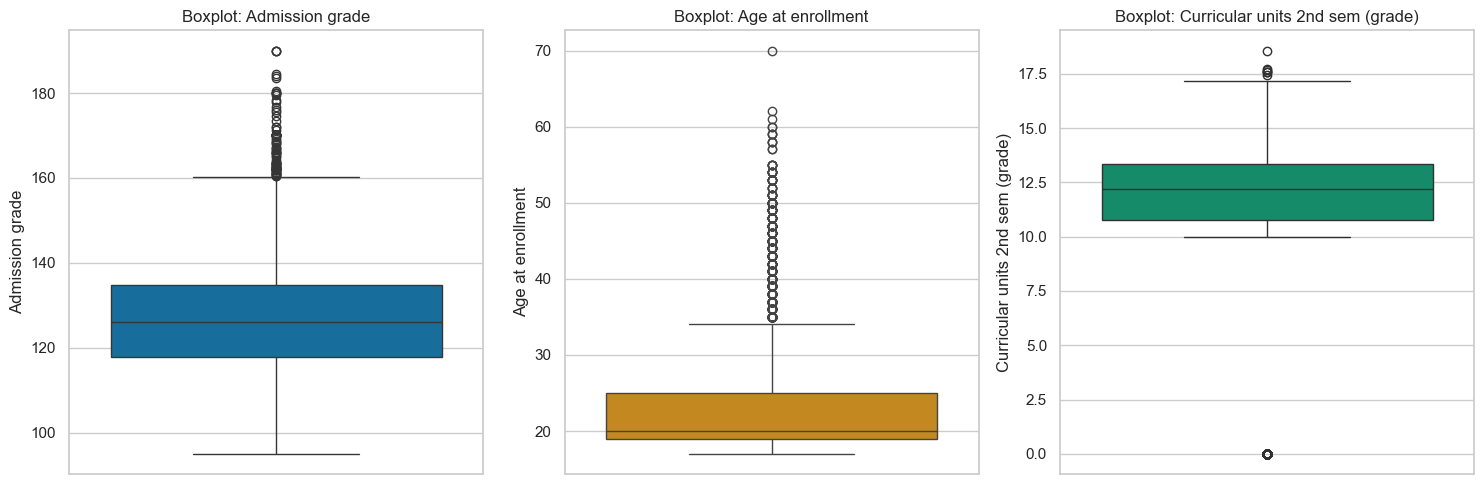

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outlier_cols = ["Admission grade", "Age at enrollment", "Curricular units 2nd sem (grade)"]
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("colorblind")[i])
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

# 7. Data Cleaning

Based on the dataset audit above:

- **Missing values:** the audit reported 0 missing values across all 37 columns, so no imputation is
  required at this stage.
- **Duplicates:** the audit reported 0 duplicate rows, so no rows are dropped.
- **Inappropriate columns:** all columns are relevant, coded predictors or the target; none are
  identifiers (e.g. no student-ID column is present) so none are dropped on that basis.
- **Data-quality issues:** the raw header for `Daytime/evening attendance` contained a stray tab
  character, which was already cleaned in the "Load Dataset" step. `Nacionality`, `Mother's/Father's
  qualification` and `Mother's/Father's occupation` are stored as integer *codes* (per the source
  data dictionary), so they are treated as categorical rather than ordinal numeric features later in
  preprocessing.

The cell below re-confirms these checks programmatically so the cleaning decision is verifiable rather
than asserted.

In [21]:
print("Missing values remaining:", df.isnull().sum().sum())
print("Duplicate rows remaining:", df.duplicated().sum())

# No rows/columns need to be dropped based on the checks above.
df_clean = df.copy()
print("Clean dataset shape:", df_clean.shape)

Missing values remaining: 0
Duplicate rows remaining: 0
Clean dataset shape: (4424, 37)


# 8. Feature Engineering

**Candidate feature:** the dataset records `enrolled` and `approved` curricular units separately for
the 1st and 2nd semester. The *ratio* of approved to enrolled units per semester is not present as a
direct column but is a natural, interpretable transformation available from the existing columns, so it
is created below as a new engineered feature: an overall **approval rate** across both semesters.

Why this feature was created:
[TEAM MEMBER TO VERIFY AND COMPLETE]

In [22]:
total_enrolled = df_clean["Curricular units 1st sem (enrolled)"] + df_clean["Curricular units 2nd sem (enrolled)"]
total_approved = df_clean["Curricular units 1st sem (approved)"] + df_clean["Curricular units 2nd sem (approved)"]

# Avoid division by zero for students with 0 enrolled units across both semesters
df_clean["approval_rate"] = np.where(total_enrolled > 0, total_approved / total_enrolled, 0.0)

df_clean[["Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)",
          "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)",
          "approval_rate"]].head()

,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),Curricular units 1st sem (approved),Curricular units 2nd sem (approved),approval_rate
0,0,0,0,0,0.000000
1,6,6,6,6,1.000000
2,6,6,0,0,0.000000
3,6,6,6,5,0.916667
4,6,6,5,6,0.916667


C:\Users\DELL\AppData\Local\Temp\ipykernel_18616\2915268005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Target", y="approval_rate", order=order, ax=ax, palette="colorblind")


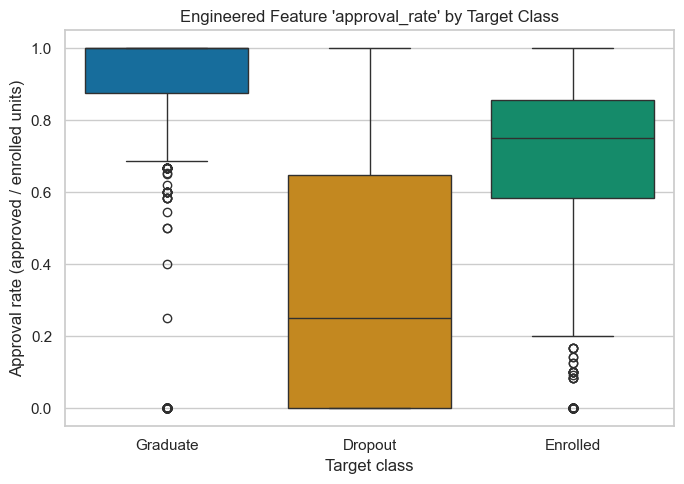

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x="Target", y="approval_rate", order=order, ax=ax, palette="colorblind")
ax.set_title("Engineered Feature 'approval_rate' by Target Class")
ax.set_xlabel("Target class")
ax.set_ylabel("Approval rate (approved / enrolled units)")
plt.tight_layout()
plt.show()

# 9. Define X and y

In [24]:
X = df_clean.drop(columns=["Target"])
y = df_clean["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
assert "Target" not in X.columns, "Target column must not be present in X"
print("Confirmed: target column is not present in X.")

X shape: (4424, 37)
y shape: (4424,)
Confirmed: target column is not present in X.


# 10. Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Test target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train shape: (3539, 37)
Test shape: (885, 37)

Train target distribution (%):
Target
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Test target distribution (%):
Target
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


# 11. Preprocessing

A `ColumnTransformer` + `Pipeline` is used so that scaling/encoding is **fit only on the training
data** and then applied (transformed) to both train and test sets, preventing data leakage.

Because every column in this dataset is already numerically coded (categorical variables are integer
category codes, not text labels), the preprocessing pipeline applies `StandardScaler` to all numeric
columns. Tree-based models (Decision Tree) do not strictly need scaling, but using the same scaled
input across all models keeps the comparison pipeline simple and consistent, and scaling numeric codes
does not harm tree-based splits.

In [26]:
numeric_features = X.columns.tolist()  # all columns are numeric-coded in this dataset

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

print("Number of features going into the preprocessing pipeline:", len(numeric_features))

Number of features going into the preprocessing pipeline: 37


# 12. Model Training and Evaluation

A reusable `evaluate_classifier()` function trains a model inside a `Pipeline` (preprocessing + estimator),
generates predictions on the held-out test set, and reports Accuracy, Weighted F1, and the Confusion
Matrix. The **same train/test split** (`X_train`/`X_test`/`y_train`/`y_test`) and the **same preprocessor**
are reused for every model to keep the comparison fair.

In [27]:
results = []
class_labels = sorted(y.unique())

def evaluate_classifier(name, estimator, X_train, y_train, X_test, y_test, preprocessor=preprocessor):
    """Fit a classifier inside a preprocessing pipeline and report standard metrics."""
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", estimator)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)

    print(f"--- {name} ---")
    print(f"Accuracy      : {acc:.4f}")
    print(f"Weighted F1   : {f1:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    results.append({"Model": name, "Accuracy": acc, "Weighted F1": f1})
    return pipe

## 12.1 Model 1 — Logistic Regression

--- Logistic Regression ---
Accuracy      : 0.7684
Weighted F1   : 0.7521


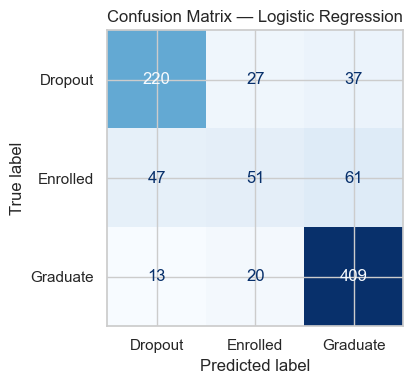

In [28]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
_ = evaluate_classifier("Logistic Regression", log_reg, X_train, y_train, X_test, y_test)

## 12.2 Model 2 — K-Nearest Neighbors

--- KNN ---
Accuracy      : 0.6746
Weighted F1   : 0.6641


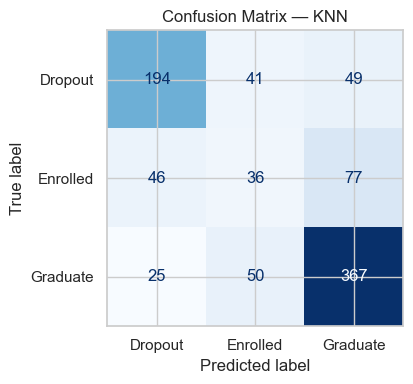

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
_ = evaluate_classifier("KNN", knn, X_train, y_train, X_test, y_test)